## Create a 2D netCDF file 

A flexible notebook to convert data files into netCDF format for upload to Datalakes. This is for 2D data (e.g. temperature at various depths measured over time -- dimension1 = depth, dimension2 = time). 

If you are not sure how many dimensions your data has, please refer to the netCDF_README file.

This python notebook is designed to be flexible to handle various different types of data. Thus it requires user entry into a few files to provide information about the data. 

In [1]:
# import the needed libraries
import os
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
import csv
from datetime import datetime
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import warnings
from collections import defaultdict
import json
# just for plotting at the end
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

In [2]:
# import the functions that exist in the folder
from utils import find_file, extract_identifier_from_pattern, sanitize_name, combine_date_time, files_to_process

__________

### Step 1: what format is your data?

**NOTE:** We are assuming that one of your dimensions is time. The other dimension (we will call dimension1) could be a variety of different things; common ones on Datalakes are depth or water pressure.


Let's collect some information about your data files. 

* Does each file only contain one dimension1 value? (e.g. file_1 is measurements of variables at a specific depth, there can be multiple files with the same depth - ex. file_1m_datecollected, file_1m_datecollected2 ...). Then proceed with this script.  

* If a single file has multiple dimension1 values (e.g. file_1 has temperature readings at different depths and depth is your dimension1), use OPTION B. See other script.

* If you have both options, then run both scripts and then you can easily combine your netCDF files (for example, using cdo mergetime or another method). 

In [3]:
# OPTION A: a file does not contain multiple dimension1 values:

# What is the variable name of dimension1? (e.g. depth, water_pressure, ...) do not include spaces
dimension1_name = 'depth'

---------

### Step 2: Find all the data files

Migrate all your data into the data folder: 'data/input/L0'

In [4]:
# the working directory is the folder that contains the full repo:
working_directory = Path.cwd().parent
# the input data directory is where all your data should be:
inputdata_directory = working_directory / 'data/input/L0'
# the script directory is where all the scripts are located:
script_directory = working_directory / 'scripts'

# What is the file naming convention? (need help with this - see README.txt -> understanding components of the code, Step 1)
# if possible, the idvalue should be associated with the dimension value (e.g. the actual value, an instrument number, a serial number ...)
# or some other identification value
data_file_pattern = 'AUTO_{idvalue}_*_data.txt'

In [5]:
### User input not required in this cell, if naming in the above cell has not changed ###

# find all the data files you have put in the data folder (L0):
file_list, file_summary = find_file(inputdata_directory, data_file_pattern)  

# create a metadata file about the data files
dfile_metadata = pd.DataFrame(list(file_summary['files_per_identifier'].items()), columns = ['ID_value', 'number_of_files'])
# add the dimension variable
dimension1_name = sanitize_name(dimension1_name) #remove any spaces, replace with underscores for ease of handling
dfile_metadata[dimension1_name] = ""

Total files found: 20
Total number of unqiue 'idvalues' found: 20


In [13]:
### This will overwrite an existing 'datafile_information.csv' if you are re-running this script ###
### User input not required in this cell ###

## save this info to a csv file
dfile_output_file = inputdata_directory.parent / 'datafile_information.csv'
## comment below if you are re-running this scripts
dfile_metadata.to_csv(dfile_output_file, index = False)

--------

### Step 3: edit the datafile_information file

In your data/input folder there is now a file labeled 'datafile_information.csv' which has a list of the unique id_values (in case each day has its own data file, for example), the number of files per id_value, and a blank column with your dimension1_name. 

**Check the information in this file and enter the dimension1 values for each id_value.**

If there are id_values you do not wish to process, simply remove the row from this file. We will be using this file to process the data files. 

__________

### Step 4: information about the format of your data files

Please fill in the below with the needed information on the format of your data file:

In [6]:
datafile_attributes = {   
            # Data collection time period (YYYY,mm,dd,hh,min,ss):
            "start_time": datetime(2025,1,17,0,0,0),
            "end_time": datetime(2025,4,22,0,0,0),

            # What line/row are the columns named? using python numbering, row0 = first line in file, row1 = second line in file, etc.
            "header_row": 0,        
    
            # Are there lines/rows between the header and when the data starts (e.g. blank rows or lines with other non-data information?)
            # how many?
            "droprows": 0, 

            # What is the separator in your data file (e.g. comma = ',', tab = '\t', space = ' ', semicolon = ';', etc)?
            "separator": ',',
    
            # What is the fill value/missing value number? (e.g. '999', 'NaN', 'NAN') 
            "_FillValue": ' ',

            # What are your date/time column(s) named in your data file? 
            # Ordered from largest to smallest (e.g. Date, Time OR Year, Month, Day, etc.) NOT in the order they are in your datafile
            "time_columns": ['Time'], 

            # Do your data files collect data in UTC time? Enter the time shift in hours or 0 if they are already in UTC:
            "time_shift": 0, 

            # What are the variable names in the data files, including the names of the time/date columns? 
            # We will pull the variables in your file based on these names (ensure they are labelled the same as in the data files)
            # Only include variables you are interested in processing:
            "var_names": ['Time', 'Temperature'], 
        }

In [7]:
### User input not required in this cell ###

# Convert start and end time to seconds since 1970 for netcdf format
sec_start_time = datafile_attributes["start_time"].timestamp()
sec_end_time = datafile_attributes["end_time"].timestamp() 

# Let's just add the dimension1 name into the datafile_attributes dictionary for later
datafile_attributes["dimension1_name"] = dimension1_name

In [8]:
### User input not required in this cell ###
### This will create/overwrite the variables.csv file if you already have one ###

# Create a variable mapping file:
var_output = inputdata_directory.parent / 'variables.csv'

# Do not edit the below:
# Column names in this file
headers = ['var_name', 'dim', 'unit', 'long_name', 'min', 'max']

# add in dimension1 to this file
dim1_metadata = {'var_name': dimension1_name, 
                 'dim': f'({dimension1_name},)',
                 'unit': '',
                 'long_name': '',
                 'min': '',
                 'max': ''}

# input the time metadata that we already know
time_metadata = {'var_name':'time',
                 'dim': '(time,)',     #var is dependent on this variable
                 'unit': 'seconds since 1970-01-01 00:00:00',
                 'long_name': 'time',
                 'min': sec_start_time - 86400,
                 'max': sec_end_time + 86400}

# let's make the variable file
with open(var_output, mode = 'w', newline='') as file:
     writer = csv.DictWriter(file, fieldnames=headers)
     writer.writeheader()
    
     # write time 
     writer.writerow(time_metadata)
     # write the other dimension in
     writer.writerow(dim1_metadata)
    
     # manage the overlapping time entries if they exist
     list3 = [item for item in datafile_attributes["var_names"] if item not in datafile_attributes["time_columns"]]
    
     # write in the other variables
     for name in list3:
         #remove any spaces as needed
         name = sanitize_name(name)
         row = {
             'var_name': name.lower(),
             'dim':'',
             'unit': '',
             'long_name': '',
             'min':'',
             'max': ''}
         writer.writerow(row)

_____________

### Step 5: edit the variable file

In your data/input folder there is now a file labeled 'variables.csv'. This information is needed for the netCDF metadata. 

**Check the information in this file and fill in the blank columns for your additional variables. Do not edit the time row.**

Info about this file:
* var_name = shorthand name for the variable (ensure there are no spaces in the var_name)
* dim = the dimension(s) this is variable is dependent on, set up as (dim1, dim2, ...) (see README.md Step 5 for more information, if you are uncertain about this)
* unit = the units (e.g. temp = degrees C etc)
* long_name = the full name for the variable (can be the same as var_name). See CF conventions, linked below, if uncertain.
* min = expected minimum value
* max = expected maximum value


CF naming conventions: [ https://cfconventions.org/Data/cf-standard-names/27/build/cf-standard-name-table.html ]

CF guidelines for construction of names: [ https://cfconventions.org/Data/cf-standard-names/docs/guidelines.html ]

---------------------------

### Step 6: Metadata

For this, you can enter the metadata here manually or use the metadata generator script. For manually entering run OPTION A, or for using a generated metadata file, use OPTION B.

*Recommended*: The metadata generator can be found on Renku, ready to use, here: [https://renkulab.io/p/ellen.knappe/datalakes-streamlit]. This will create a JSON file in the DataCite format, and should be included in your data upload. Alternatively, you can run it on your local machine by forking the repo from the Eawag Gitlab [ https://gitlab.eawag.ch/ellen.knappe/datalakes_streamlit ] or Github [ https://github.com/eknappe/metadata_generator ]. We recommend using the DataCite format because this format is interoperable, machine-readable, and recommended by the ETH Domain.

We will be using ACDD conventions for the netCDF. See here for more info: [ https://wiki.esipfed.org/Attribute_Convention_for_Data_Discovery_1-3 ].

Once you generate the metadata file, put it in the working_directory.

**OPTION A: No metadata file? Input information here and skip to Step 7. If you have a metadata file, skip this cell.** 

In [10]:
## SKIP THIS SECTION IF YOU CREATED A METADATA FILE ##
# else, input the required fields
general_attributes = {
            "title": " ",
            "creator_name": " ",
            "institution": " ",
            "keywords": "[keyword1,keyword2,..] ",
            "Conventions": "ACDD-1.3",
            "description": " ", #abstract/description of your data
            "source": " ", #add in the name of the lakes here and any other project info needed
            "license": " "
        }

__OPTION B: I have a metadata file:__

In [9]:
# Do you have a metadata file? 

# we recommend putting it the top level directory, e.g. the working_directory that was set at the start of this notebook 
# else define it here
file_location = working_directory
print(f"This is where you should put your metadata file: {working_directory}")

This is where you should put your metadata file: /Users/knappeel/Documents/coding/datalakes/data_convert


In [10]:
## SKIP THIS CELL AND THE NEXT CELL IF YOU ADDED METADATA MANUALLY in the above cell ##

# read in the json metadata file
jfilename = 'your_metadata_file.json'

jfilename = file_location / jfilename

In [11]:
## SKIP THIS CELL AND THE NEXT CELL IF YOU ADDED METADATA MANUALLY ##
## User input not required in this cell ##

# Read in the metadata file provided
with open(jfilename, mode = 'r', encoding = "utf-8") as read_file:
    metadata_json = json.load(read_file)

# extract the needed information from the json metadata file 
title = metadata_json['data']['attributes']['titles'][0]['title']
creator_name = metadata_json['data']['attributes']['creators'][0]['name']
institution = metadata_json['data']['attributes']['creators'][0]['affiliation'][0]['name']
keywords = ', '.join([key['subject'] for key in metadata_json['data']['attributes']['subjects']]) #extracts the keywords if there are multiple
description = metadata_json['data']['attributes']['descriptions'][0]['description']
source =', '.join([geo['geoLocationPlace'] for geo in metadata_json['data']['attributes']['geoLocations']]) #extracts the location if there are multiple
license = metadata_json['data']['attributes']['rightsList'][0]['rights']

# make a dictionary for ease of adding it to the netCDF file
general_attributes = {
            "title": title,
            "creator_name": creator_name,
            "institution": institution,
            "keywords": keywords,
            "Conventions": "ACDD-1.3",
            "description": description,
            "source": source, 
            "license": license
        }

print(general_attributes)

{'title': 'Test: Thermistor data from Jemina', 'creator_name': 'Ellen Knappe', 'institution': 'Lib4RI - Library for the Research Institutes within the ETH Domain: Eawag\\, Empa\\, PSI & WSL', 'keywords': 'temperature, depth', 'Conventions': 'ACDD-1.3', 'description': 'This is some test data kindly provided by Jemima to test this all out. ', 'source': 'Lake Zug', 'license': 'CC BY 4.0'}


______________

### Step 7: read in all the data files

It's show time. 

In [14]:
# no user input needed for this cell #

# first we will cycle through all the files, based on the datafile_information.csv file
# open them, based on the information provided, then combine them into a netcdf 
files_information = pd.read_csv(dfile_output_file)

# convert into a list for the function
#file_identifiers = files_information['ID_value'].astype(str).tolist()

# get all the file locations (e.g. the path on your computer):
files_locations = files_to_process(inputdata_directory, data_file_pattern, files_information)

# lets put in a little check to make sure the dimension1 values were entered by the user
if files_locations['dim1'].isna().any() or (files_locations['dim1'] == '').any():
    print(f"!!WARNING!! Please ensure you enter the {datafile_attributes["dimension1_name"]} values in {dfile_output_file} file and rerun this cell")

#just a little double check here
print(f"Number of files to process: {len(files_locations)}")
print(f"Number of unique {datafile_attributes['dimension1_name']}s to be processed: {len(files_information)}")

Number of files to process: 19
Number of unique depths to be processed: 19


In [16]:
# no user input needed for this cell #

# accumulate all the files
# depending on how many files, this could take a minute
all_datasets = []

# loop through all the files listed
for ff in range(0,len(files_locations)):
    #define the file path and value of the dimension1
    file = files_locations.file_path.loc[ff]
    dim1v = float(files_locations.dim1.loc[ff])
    
    #read in the file
    #note for skiprows we are assuming the columns are correctly named, so we are extracting the data based on the name of the columns
    #if the line above the data is not the listed columns, then adjust this accordingly
    data = pd.read_csv(file, sep = datafile_attributes["separator"], header = datafile_attributes["header_row"], 
                       usecols = datafile_attributes["var_names"]) 

    #if there are rows between the header and the data, we will drop those
    #if there are none, then nothing will happen
    if datafile_attributes["droprows"] > 0:
        for ii in range(0, datafile_attributes["droprows"]):
            data = data.drop(index=ii)
   
    # convert the time column(s) into the correct format
    # this will convert the date column into seconds since 1970 (Unix format)
    data_with_time = combine_date_time(data, datafile_attributes["time_columns"], datafile_attributes["separator"])

    #apply time shift if needed
    data_with_time["time"] = data_with_time["time"] + (datafile_attributes["time_shift"]*3600)

    # add the dimension1 value and with the correct name
    data_with_time[datafile_attributes["dimension1_name"]] = dim1v
    
    #for ease of the rest of the coding
    dim1_name = datafile_attributes["dimension1_name"]
    
    # list the data columns (without time and dim1 since these are coordinate variables)
    data_cols = [c for c in data_with_time.columns if c not in {"time", dim1_name}]

    # build the xr data set for the file: dims = time, dim1
    ds_file = xr.Dataset(
        {
            var: xr.DataArray(
                data_with_time[var].values[:, np.newaxis], #shape (time, 1)
                dims=["time", dim1_name],)
            for var in data_cols # only using the non-dimension columns (e.g. these are the variables)
        },
        coords={
            "time": data_with_time["time"].values,
            dim1_name: [dim1v], # the single depth value
        },
    )
    all_datasets.append(ds_file) #make one super dataset with everything

# edit the super dataset and format it correctly
full_ds = xr.concat(all_datasets, dim = dim1_name, join = "outer") # expand along dim1
full_ds = full_ds.sortby(["time", dim1_name])

# check the files don't have overlap
time_counts = pd.Series(full_ds.time.values).duplicated(keep=False)

if time_counts.any():
    warnings.warn(
        f"WARNING: overlapping time values detected across files."
        f"Review your input files for overlapping data. Keeping the first occurrence.", stacklevel =2)

# add in the attributes (the metadata info into the netCDF)
full_ds.attrs = general_attributes

print('Files compiled into variable called full_ds')

Files compiled into variable called full_ds


### Step 8: check the data

Now, let's check the data. First, just check out the netCDF information. 

In [17]:
print(full_ds)

<xarray.Dataset> Size: 137MB
Dimensions:      (time: 858983, depth: 19)
Coordinates:
  * time         (time) int64 7MB 1736920800 1736920810 ... 1745510620
  * depth        (depth) float64 152B 59.0 64.0 69.0 74.0 ... 139.0 144.0 149.0
Data variables:
    Temperature  (time, depth) float64 131MB 17.76 18.0 17.8 ... nan nan nan
Attributes:
    title:         Test: Thermistor data from Jemina
    creator_name:  Ellen Knappe
    institution:   Lib4RI - Library for the Research Institutes within the ET...
    keywords:      temperature, depth
    Conventions:   ACDD-1.3
    description:   This is some test data kindly provided by Jemima to test t...
    source:        Lake Zug
    license:       CC BY 4.0


Now let's plot the data to check it out. 

In [25]:
# name of variable would you like to plot (as listed in the netCDF)
variabletoplot = "variable_name_as_labeled_in_netCDF"

# set some bounds so the colorbar makes more sense 
# feel free to edit to your needs, but we find these bounds work well for visualizing the data
data = full_ds[variabletoplot].values

# going to remove the "tails" of data to define the colorbar, this is just for plotting, it does not affect the data
vmin = np.nanpercentile(data, 5)
vmax = np.nanpercentile(data, 95)

# font size
lsize = 20

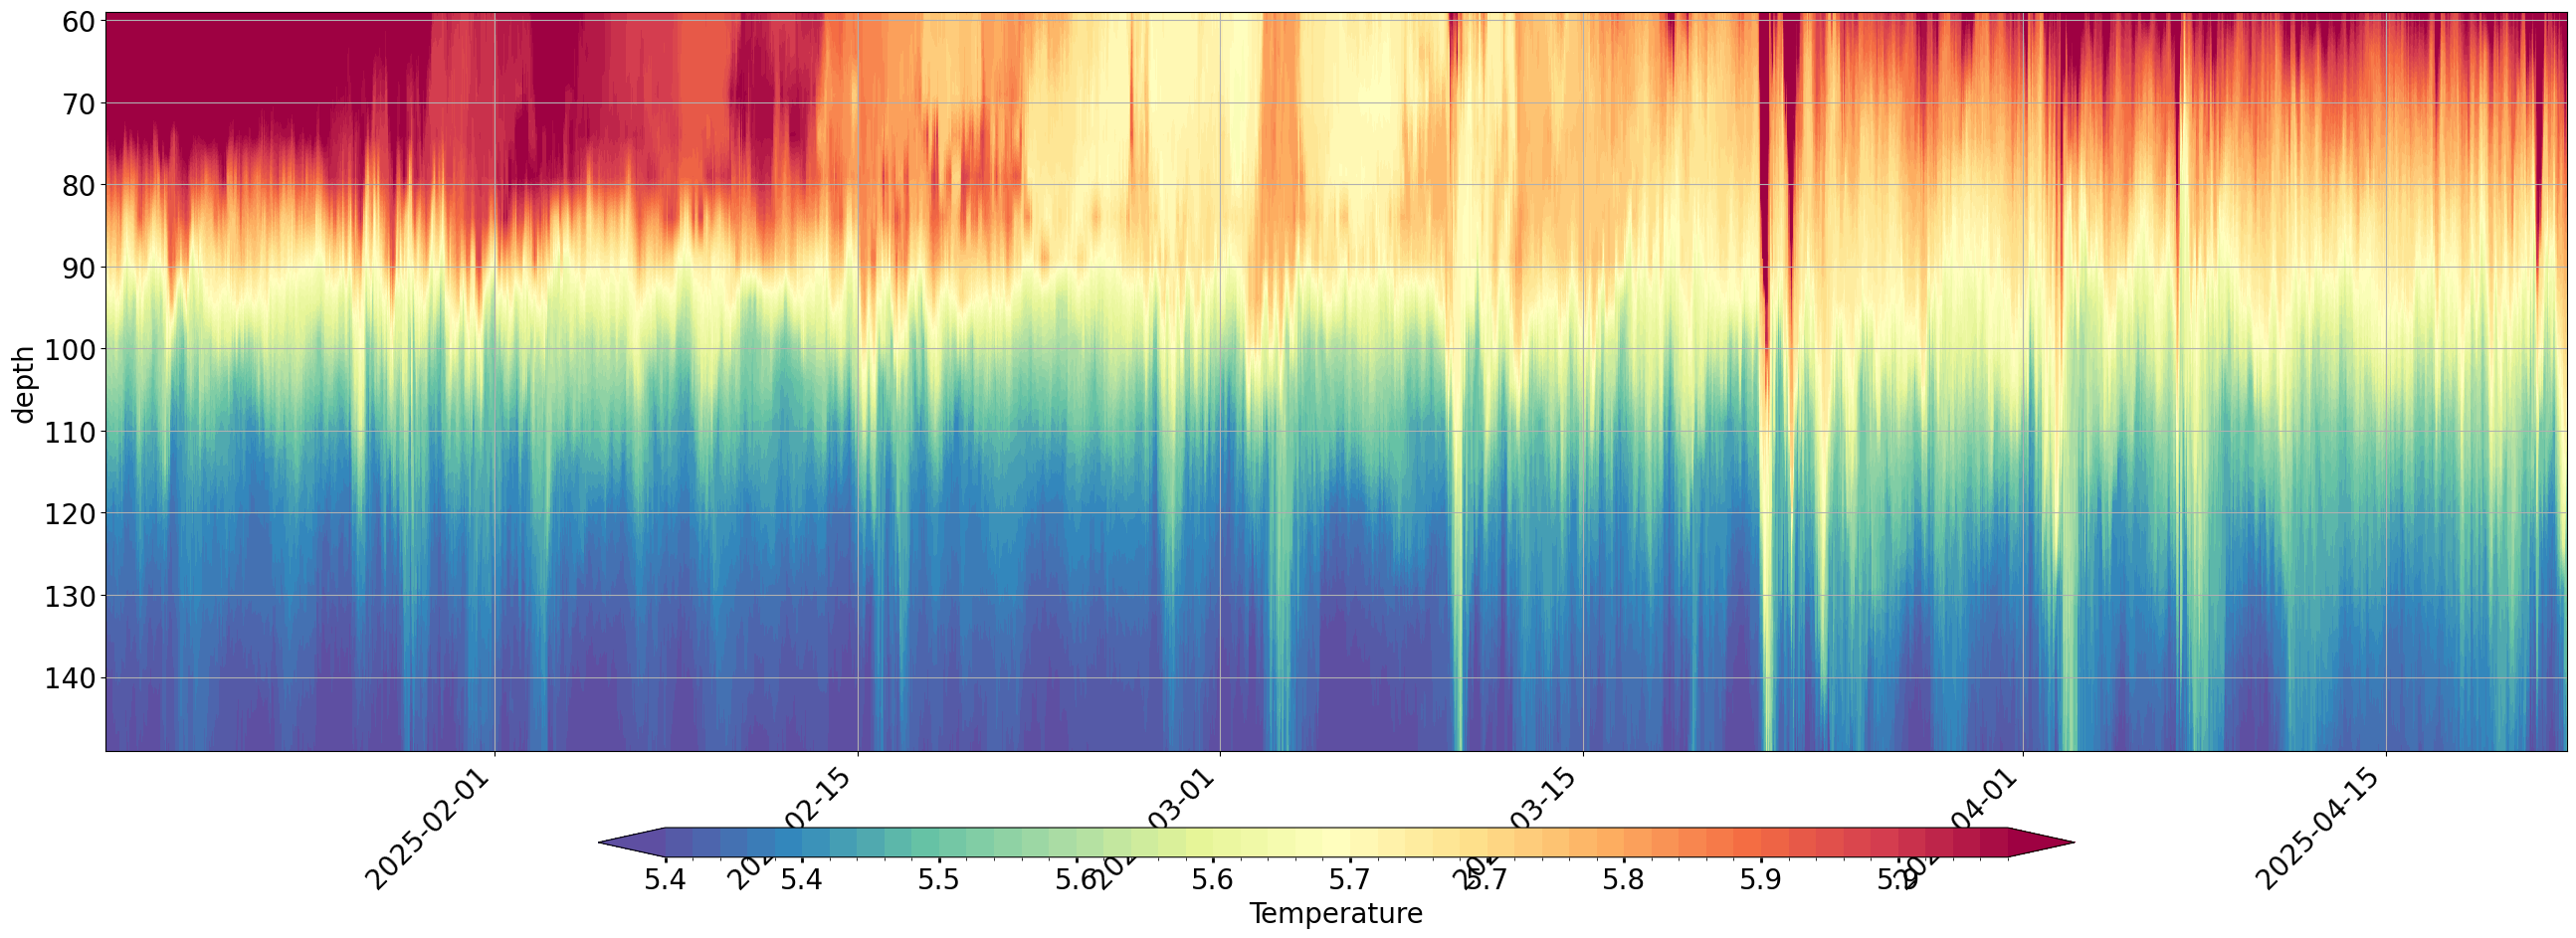

In [43]:
# user input not needed in this cell 
# plot should show up below this cell

# Modified from Jemima Rama's code. Thanks, Jemina!

# convert unix timestamps to datetime64 for plotting purposes - so folks can read them :)
plot_ds = full_ds.assign_coords(time=pd.to_datetime(full_ds["time"].values, unit="s"))

# create the plot
fig, ax = plt.subplots(1, figsize=(26, 10))
contour = plot_ds[variabletoplot].plot.contourf(x = "time", y = dim1_name, #set the axes
    levels=50, cmap='Spectral_r', add_colorbar=False, vmin=vmin, vmax=vmax)

# invert the y-axis since the depths are depths from the surface, can remove this is your  
ax.invert_yaxis()  

# format xaxis as readable dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=45, ha='right')

ax.set_xlim(pd.Timestamp(datafile_attributes['start_time']), pd.Timestamp(datafile_attributes['end_time']))

plt.grid('minor')
ax.tick_params(axis='both', which='major', labelsize=lsize)  # adjust parameters as needed

# add horizontal colorbar
cbar = fig.colorbar(contour, ax=ax, orientation='horizontal', pad=0.08, shrink=0.6, aspect=50)

# adjust the colorbar's tick parameters
cbar.ax.tick_params(labelsize=lsize, width=2)  # increase label size and tick width
cbar.ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
cbar.set_label(variabletoplot, fontsize=lsize)

plt.ylabel(dim1_name, fontsize=lsize)
plt.xlabel('', fontsize=lsize)

plt.tight_layout()

### Step 9: Save the data! 

In [42]:
filename_prefix= 'your_dataset_name_here'
save_directory = working_directory / 'data/output'

# Datalakes format has a netcdf file for each month, so that's what we will do
# note if you just want a singular netcdf, you can use full_ds.to_netcdf(filelocation/filename)

# times is recorded in seconds since 1970, decode for labelling
decoded_times = pd.to_datetime(full_ds.time.values, unit='s')

# group by year-month string
labels = pd.Series(decoded_times).dt.strftime("%Y_%m").values

for label in np.unique(labels):
    mask = labels == label
    ds_month = full_ds.isel(time = mask)

    #get the first day of data in the month for labelling
    first_day = decoded_times[mask].min().day

    filename = os.path.join(save_directory, f"{filename_prefix}_{label}_{first_day:02d}.nc")
    ds_month.to_netcdf(filename)
    print(f"Saved {filename}")

Saved /Users/knappeel/Documents/coding/datalakes/data_convert/data/output/testing_filename_2025_01_15.nc
Saved /Users/knappeel/Documents/coding/datalakes/data_convert/data/output/testing_filename_2025_02_01.nc
Saved /Users/knappeel/Documents/coding/datalakes/data_convert/data/output/testing_filename_2025_03_01.nc
Saved /Users/knappeel/Documents/coding/datalakes/data_convert/data/output/testing_filename_2025_04_01.nc
